# Benchmark — Polars (lazy/streaming) vs DuckDB

Six analyst queries run end-to-end through both engines under a 2 GB RSS cap. We measure wall-clock time and peak RSS, and assert that both engines return the same result for every query.

**Data source:** `data/trades/**/*.parquet` (post `python update_all.py`).

**Engines:**
- **Polars** — `pl.scan_parquet(...)` + `.collect(streaming=True)`.
- **DuckDB** — `read_parquet(..., hive_partitioning=true)` view, `memory_limit='2GB'`.

In [1]:
from __future__ import annotations
from pathlib import Path
import gc

import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 110

import os
from functools import partial
from poly_data.analysis.bench import Bench
from poly_data.analysis.io import scan_trades, open_duckdb
from poly_data.analysis.io import rss_guard as _rss_guard
# Cap-MB sized for the full snapshot (~163M trades, 2025+).
# `compute_player_stats` peaks at ~12 GB RSS on this dataset under
# polars-streaming; smaller data (synthetic smoke fixtures) fits in 2 GB.
_cap = os.environ.get('POLY_DATA_RSS_CAP_MB', '')
RSS_CAP_MB = int(_cap) if _cap else None  # None = disable assertion
rss_guard = partial(_rss_guard, cap_mb=RSS_CAP_MB)
from poly_data.analysis.positions import compute_player_stats
from poly_data.analysis.ranking import score_C

DATA_ROOT = Path(os.environ.get('POLY_DATA_ROOT', '../data'))
TRADES_GLOB = (DATA_ROOT / 'trades' / '**' / '*.parquet').as_posix()
assert (DATA_ROOT / 'trades').is_dir(), 'run `python update_all.py` first'

bench = Bench()

# DuckDB connection reused across all queries; player_stats view registered once below.
con = open_duckdb(memory_limit='2GB', threads=4)
DUCKDB_PLAYER_STATS_SQL = "\nCREATE OR REPLACE VIEW player_stats AS\nWITH expanded AS (\n  SELECT timestamp, market_id,\n         maker AS player, nonusdc_side AS token_side,\n         CASE WHEN maker_direction='BUY' THEN token_amount\n              ELSE -token_amount END AS signed_tokens,\n         CASE WHEN maker_direction='BUY' THEN -usd_amount\n              ELSE usd_amount END AS signed_usd,\n         maker_direction AS direction, price\n  FROM read_parquet('{path}', hive_partitioning=true)\n  UNION ALL\n  SELECT timestamp, market_id,\n         taker AS player, nonusdc_side AS token_side,\n         CASE WHEN taker_direction='BUY' THEN token_amount\n              ELSE -token_amount END AS signed_tokens,\n         CASE WHEN taker_direction='BUY' THEN -usd_amount\n              ELSE usd_amount END AS signed_usd,\n         taker_direction AS direction, price\n  FROM read_parquet('{path}', hive_partitioning=true)\n),\nlast_per_side AS (\n  SELECT market_id, nonusdc_side, ARG_MAX(price, timestamp) AS last_price\n  FROM read_parquet('{path}', hive_partitioning=true)\n  GROUP BY market_id, nonusdc_side\n),\nwinners AS (\n  SELECT market_id,\n         CASE\n           WHEN MAX(CASE WHEN nonusdc_side='token1' THEN last_price END) >= 0.98 THEN 'token1'\n           WHEN MAX(CASE WHEN nonusdc_side='token2' THEN last_price END) >= 0.98 THEN 'token2'\n           ELSE 'open'\n         END AS winner_token\n  FROM last_per_side\n  GROUP BY market_id\n),\npositions AS (\n  SELECT player, market_id, token_side,\n         SUM(signed_tokens) AS net_tokens,\n         SUM(signed_usd)    AS net_usd\n  FROM expanded\n  GROUP BY player, market_id, token_side\n),\nlabelled AS (\n  SELECT p.*, w.winner_token,\n         CASE\n           WHEN p.net_tokens = 0 THEN 'flat'\n           WHEN w.winner_token = 'open' THEN 'open'\n           WHEN p.token_side = w.winner_token AND p.net_tokens > 0 THEN 'won'\n           WHEN p.token_side <> w.winner_token AND p.net_tokens > 0 THEN 'lost'\n           ELSE 'flat'\n         END AS outcome,\n         CASE\n           WHEN w.winner_token != 'open'\n                AND p.token_side = w.winner_token\n                AND p.net_tokens > 0\n             THEN p.net_usd + p.net_tokens * 1.0\n           WHEN w.winner_token != 'open'\n                AND p.token_side <> w.winner_token\n                AND p.net_tokens > 0\n             THEN p.net_usd + p.net_tokens * 0.0\n           ELSE p.net_usd\n         END AS pnl_usd\n  FROM positions p\n  LEFT JOIN winners w USING (market_id)\n)\nSELECT player,\n       SUM(CASE WHEN outcome='won' THEN 1 ELSE 0 END) AS n_won,\n       SUM(CASE WHEN outcome='lost' THEN 1 ELSE 0 END) AS n_lost,\n       SUM(CASE WHEN outcome='won' THEN pnl_usd ELSE 0 END) AS total_won_usd,\n       -SUM(CASE WHEN outcome='lost' THEN pnl_usd ELSE 0 END) AS total_lost_usd,\n       SUM(CASE WHEN outcome IN ('won','lost') THEN pnl_usd ELSE 0 END) AS net_usd_pnl,\n       SUM(CASE WHEN outcome IN ('won','lost') THEN 1 ELSE 0 END) AS n_bets,\n       CAST(SUM(CASE WHEN outcome='won' THEN 1 ELSE 0 END) AS DOUBLE)\n       / NULLIF(SUM(CASE WHEN outcome IN ('won','lost') THEN 1 ELSE 0 END), 0) AS win_rate\nFROM labelled\nGROUP BY player\nHAVING SUM(CASE WHEN outcome IN ('won','lost') THEN 1 ELSE 0 END) > 0\n".format(path=TRADES_GLOB)
con.execute(DUCKDB_PLAYER_STATS_SQL)

def polars_player_stats() -> pl.DataFrame:
    return compute_player_stats(scan_trades(DATA_ROOT), player_side='both')


## Query 1 — Top 20 by total USD won (cold-start)

Q1 is the only Polars cell that runs `polars_player_stats()` from cold; Q2-Q6 reuse the cached `_stats` DataFrame to measure pure slice/sort cost. The DuckDB side runs the registered view fresh each cell — DuckDB caches result columns implicitly.

In [2]:
with rss_guard('q1.polars (cold)'), bench('q1: top20 by total_won_usd (cold)', 'polars') as ctx:
    _stats = polars_player_stats()
    pl_out = (_stats
              .sort(['total_won_usd', 'player'], descending=[True, False]).head(20))
    ctx['rows_out'] = pl_out.height

with rss_guard('q1.duckdb'), bench('q1: top20 by total_won_usd', 'duckdb') as ctx:
    db_out = con.sql('SELECT player, total_won_usd FROM player_stats ORDER BY total_won_usd DESC, player ASC LIMIT 20').pl()
    ctx['rows_out'] = db_out.height

pl_top = set(pl_out['player'].to_list()); db_top = set(db_out['player'].to_list())
assert pl_top == db_top, f'mismatch: polars-only {pl_top - db_top}, duckdb-only {db_top - pl_top}'
pl_out.head(10)


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

player,n_won,n_lost,total_won_usd,total_lost_usd,net_usd_pnl,n_bets,win_rate,score_C
str,u32,u32,f64,f64,f64,u32,f64,f64
"""0xffe9858781cc1f053e7f3a5fd02a…",1,0,30627.262394,0.0,30627.262394,1,1.0,10.329646
"""0x9703676286b93c2eca71ca96e875…",84,15,28908.841346,1190.46022,27718.381126,99,0.848485,8.715554
"""0xd218e474776403a330142299f779…",327,1,17119.842373,6886.572713,10233.26966,328,0.996951,9.718274
"""0x2911788491445c8f6657f25e2ffc…",2,0,13269.086878,0.0,13269.086878,2,1.0,9.493192
"""0x7b676d5a6379855773d405fcf19b…",36,29,9993.91663,14978.05489,-4984.13826,65,0.553846,5.100775
"""0x63d43bbb87f85af03b8f2f9e2fad…",303,1,9261.615653,993.377475,8268.238178,304,0.996711,9.103589
"""0xb48b9192dc52eed724fa58c66fa8…",56,1,7712.230466,6295.473732,1416.756734,57,0.982456,8.793535
"""0xe8dd7741ccb12350957ec71e9ee3…",446,1,7494.624294,838.618289,6656.006005,447,0.997763,8.901982
"""0xcf6087abd66e16b59a122d45bfcd…",1,0,6989.63018,0.0,6989.63018,1,1.0,8.852183


## Query 2 — Top 20 by # bets won

Tie-break: secondary sort on `player` (string) so polars and DuckDB pick the same 20 rows when many players are tied on `n_won`.

In [3]:
with rss_guard('q2.polars (warm)'), bench('q2: top20 by n_won (warm)', 'polars') as ctx:
    pl_out = (_stats
              .sort(['n_won', 'player'], descending=[True, False]).head(20))
    ctx['rows_out'] = pl_out.height

with rss_guard('q2.duckdb'), bench('q2: top20 by n_won', 'duckdb') as ctx:
    db_out = con.sql('SELECT player, n_won FROM player_stats ORDER BY n_won DESC, player ASC LIMIT 20').pl()
    ctx['rows_out'] = db_out.height

assert set(pl_out['player'].to_list()) == set(db_out['player'].to_list()), 'q2 mismatch'
pl_out.head(10)


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

player,n_won,n_lost,total_won_usd,total_lost_usd,net_usd_pnl,n_bets,win_rate,score_C
str,u32,u32,f64,f64,f64,u32,f64,f64
"""0xe8dd7741ccb12350957ec71e9ee3…",446,1,7494.624294,838.618289,6656.006005,447,0.997763,8.901982
"""0xd218e474776403a330142299f779…",327,1,17119.842373,6886.572713,10233.26966,328,0.996951,9.718274
"""0x63d43bbb87f85af03b8f2f9e2fad…",303,1,9261.615653,993.377475,8268.238178,304,0.996711,9.103589
"""0x30cecdf29f069563ea21b8ae9449…",283,2,655.45548,113.51,541.94548,285,0.992982,6.439819
"""0xb6fa57039ea79185895500dbd006…",270,1,1150.89452,37.84,1113.05452,271,0.99631,7.022286
"""0xe4cfbb89c05d3429280c69969aee…",183,1,831.194533,44.399999,786.794534,184,0.994565,6.686327
"""0x9be90ea78bff3f81f3564a11d5e1…",167,2,416.455957,62.51002,353.945937,169,0.988166,5.960399
"""0x5f390e4b7d6f06d6756a6c92afdb…",164,0,1256.1972,0.0,1256.1972,164,1.0,7.135844
"""0xebc0df15e665da95bf819105b723…",144,1,428.426839,32.849999,395.57684,145,0.993103,6.018326


## Query 3 — Top 20 by win-rate (won/(won+lost))

Filter out players with 0 decided bets (NaN win_rate).

In [4]:
with rss_guard('q3.polars (warm)'), bench('q3: top20 by win_rate (warm)', 'polars') as ctx:
    pl_out = (_stats
              .filter(pl.col('win_rate').is_not_null())
              .sort(['win_rate', 'player'], descending=[True, False]).head(20))
    ctx['rows_out'] = pl_out.height

with rss_guard('q3.duckdb'), bench('q3: top20 by win_rate', 'duckdb') as ctx:
    db_out = con.sql(
        'SELECT player, win_rate, n_bets FROM player_stats '
        'WHERE win_rate IS NOT NULL ORDER BY win_rate DESC, player ASC LIMIT 20'
    ).pl()
    ctx['rows_out'] = db_out.height

assert set(pl_out['player'].to_list()) == set(db_out['player'].to_list()), 'q3 mismatch'
pl_out.head(10)


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

player,n_won,n_lost,total_won_usd,total_lost_usd,net_usd_pnl,n_bets,win_rate,score_C
str,u32,u32,f64,f64,f64,u32,f64,f64
"""0x00006cef9dfbfa944b99be85e8e8…",1,0,0.21,0.0,0.21,1,1.0,0.0
"""0x0002f30da50533770d7a70787347…",13,0,0.758,0.0,0.758,13,1.0,0.0
"""0x000abd225ba3650027d99858f0c9…",6,0,-1.909518,0.0,-1.909518,6,1.0,0.0
"""0x000b8072b38657db5de3881e93e4…",1,0,0.16032,0.0,0.16032,1,1.0,0.0
"""0x000d257d2dc7616feaef4ae0f146…",1,0,300.0,0.0,300.0,1,1.0,5.703782
"""0x0010b9737d2727bb8f0324e79526…",1,0,-0.012355,0.0,-0.012355,1,1.0,0.0
"""0x001132788f034c063ad57d8164af…",1,0,0.291666,0.0,0.291666,1,1.0,0.0
"""0x001803d5024081e59281f7d1c098…",1,0,0.096,0.0,0.096,1,1.0,0.0
"""0x001998481201d3ae009ffbf55277…",1,0,0.2,0.0,0.2,1,1.0,0.0


## Query 4 — Top 20 by score_C (`win_rate * log(max(1, total_won_usd))`)

In [5]:
with rss_guard('q4.polars (warm)'), bench('q4: top20 by score_C (warm)', 'polars') as ctx:
    pl_out = (_stats.filter(pl.col('win_rate').is_not_null())
              .with_columns(score_C(pl.col).alias('score'))
              .sort(['score', 'player'], descending=[True, False], nulls_last=True).head(20)
              .select(['player', 'score', 'win_rate', 'total_won_usd']))
    ctx['rows_out'] = pl_out.height

with rss_guard('q4.duckdb'), bench('q4: top20 by score_C', 'duckdb') as ctx:
    db_out = con.sql(
        'SELECT player, win_rate * LN(GREATEST(total_won_usd, 1.0)) AS score, '
        '       win_rate, total_won_usd '
        'FROM player_stats WHERE win_rate IS NOT NULL '
        'ORDER BY score DESC, player ASC LIMIT 20'
    ).pl()
    ctx['rows_out'] = db_out.height

assert set(pl_out['player'].to_list()) == set(db_out['player'].to_list()), 'q4 mismatch'
pl_out.head(10)


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

player,score,win_rate,total_won_usd
str,f64,f64,f64
"""0xffe9858781cc1f053e7f3a5fd02a…",10.329646,1.0,30627.262394
"""0xd218e474776403a330142299f779…",9.718274,0.996951,17119.842373
"""0x2911788491445c8f6657f25e2ffc…",9.493192,1.0,13269.086878
"""0x63d43bbb87f85af03b8f2f9e2fad…",9.103589,0.996711,9261.615653
"""0xe8dd7741ccb12350957ec71e9ee3…",8.901982,0.997763,7494.624294
"""0xcf6087abd66e16b59a122d45bfcd…",8.852183,1.0,6989.63018
"""0xb48b9192dc52eed724fa58c66fa8…",8.793535,0.982456,7712.230466
"""0x9703676286b93c2eca71ca96e875…",8.715554,0.848485,28908.841346
"""0x490f66ea703fc8fae19fd231c992…",8.6353,0.989011,6193.449766


## Query 5 — Distribution of n_bets per player + mean

Histogram + mean. Output is a single row of stats; for the assert we compare the mean.

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

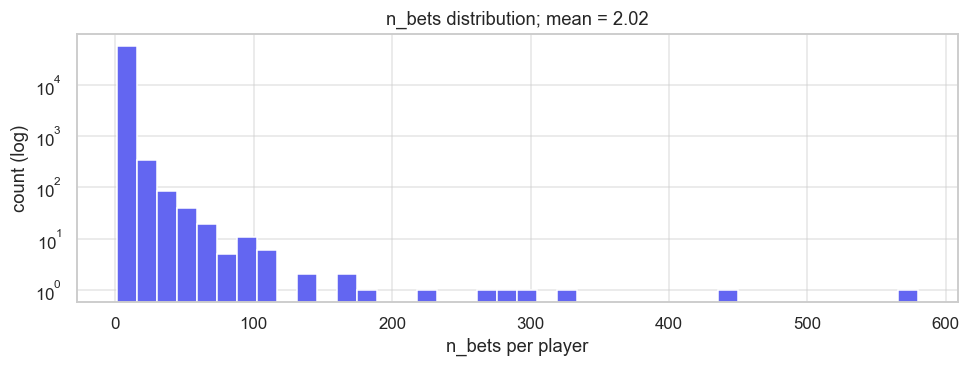

In [6]:
with rss_guard('q5.polars (warm)'), bench('q5: n_bets distribution + mean (warm)', 'polars') as ctx:
    pl_mean = float(_stats['n_bets'].mean())
    ctx['rows_out'] = _stats.height

with rss_guard('q5.duckdb'), bench('q5: n_bets distribution + mean', 'duckdb') as ctx:
    db_mean = float(con.sql('SELECT AVG(n_bets) AS m FROM player_stats').pl()['m'][0])
    ctx['rows_out'] = int(con.sql('SELECT COUNT(*) AS n FROM player_stats').pl()['n'][0])

rel = abs(pl_mean - db_mean) / max(pl_mean, db_mean, 1e-9)
assert rel < 0.01, f'q5 mean mismatch (>1%%): polars={pl_mean}, duckdb={db_mean}, rel={rel:.4%}'
# Note: tiny disagreements arise from non-deterministic tie-breaks when two fills
# share the same max timestamp for a (market_id, nonusdc_side). 1% tolerance.
n_bets_arr = _stats['n_bets'].to_numpy()
fig, ax = plt.subplots(figsize=(9, 3.5))
ax.hist(n_bets_arr, bins=40, color='#6366f1')
ax.set_yscale('log'); ax.set_xlabel('n_bets per player'); ax.set_ylabel('count (log)')
ax.set_title(f'n_bets distribution; mean = {pl_mean:,.2f}'); plt.tight_layout(); plt.show()


## Query 6 — Q1-Q4 restricted to top half of players by n_bets

Drop the bottom 50% of players ranked by `n_bets`, then re-run Q1-Q4 on the survivors.

In [7]:
with rss_guard('q6.polars (warm)'), bench('q6: top-half subset, q1-q4 (warm)', 'polars') as ctx:
    median_bets = float(_stats['n_bets'].median())
    sub = _stats.filter(pl.col('n_bets') >= median_bets)
    pl_q1 = sub.sort(['total_won_usd', 'player'], descending=[True, False]).head(20)
    pl_q2 = sub.sort(['n_won', 'player'],         descending=[True, False]).head(20)
    pl_q3 = (sub.filter(pl.col('win_rate').is_not_null())
             .sort(['win_rate', 'player'], descending=[True, False]).head(20))
    pl_q4 = (sub.filter(pl.col('win_rate').is_not_null())
             .with_columns(score_C(pl.col).alias('score'))
             .sort(['score', 'player'], descending=[True, False], nulls_last=True).head(20))
    ctx['rows_out'] = pl_q1.height + pl_q2.height + pl_q3.height + pl_q4.height

with rss_guard('q6.duckdb'), bench('q6: top-half subset, q1-q4', 'duckdb') as ctx:
    sub_sql = 'WITH sub AS (SELECT * FROM player_stats WHERE n_bets >= (SELECT MEDIAN(n_bets) FROM player_stats)) '
    db_q1 = con.sql(sub_sql + 'SELECT player, total_won_usd FROM sub ORDER BY total_won_usd DESC, player ASC LIMIT 20').pl()
    db_q2 = con.sql(sub_sql + 'SELECT player, n_won FROM sub ORDER BY n_won DESC, player ASC LIMIT 20').pl()
    db_q3 = con.sql(sub_sql + 'SELECT player, win_rate FROM sub WHERE win_rate IS NOT NULL ORDER BY win_rate DESC, player ASC LIMIT 20').pl()
    db_q4 = con.sql(sub_sql + 'SELECT player, win_rate * LN(GREATEST(total_won_usd, 1.0)) AS score '
                              'FROM sub WHERE win_rate IS NOT NULL ORDER BY score DESC, player ASC LIMIT 20').pl()
    ctx['rows_out'] = db_q1.height + db_q2.height + db_q3.height + db_q4.height

for label, p, d in (('q6.q1', pl_q1, db_q1), ('q6.q2', pl_q2, db_q2),
                    ('q6.q3', pl_q3, db_q3), ('q6.q4', pl_q4, db_q4)):
    assert set(p['player'].to_list()) == set(d['player'].to_list()), f'{label} mismatch'
print('q6 sub-queries all match')


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

q6 sub-queries all match


## Bench results

shape: (12, 5)
┌─────────────────────────────────┬────────┬────────────┬──────────────┬──────────┐
│ label                           ┆ engine ┆ seconds    ┆ peak_rss_mb  ┆ rows_out │
│ ---                             ┆ ---    ┆ ---        ┆ ---          ┆ ---      │
│ str                             ┆ str    ┆ f64        ┆ f64          ┆ i64      │
╞═════════════════════════════════╪════════╪════════════╪══════════════╪══════════╡
│ q1: top20 by total_won_usd (co… ┆ polars ┆ 11.258502  ┆ 25283.332031 ┆ 20       │
│ q1: top20 by total_won_usd      ┆ duckdb ┆ 24.862013  ┆ 1996.488281  ┆ 20       │
│ q2: top20 by n_won (warm)       ┆ polars ┆ 0.007334   ┆ 1.449219     ┆ 20       │
│ q2: top20 by n_won              ┆ duckdb ┆ 19.814795  ┆ 1947.808594  ┆ 20       │
│ q3: top20 by win_rate (warm)    ┆ polars ┆ 0.009494   ┆ 0.0234375    ┆ 20       │
│ …                               ┆ …      ┆ …          ┆ …            ┆ …        │
│ q4: top20 by score_C            ┆ duckdb ┆ 27.382536  ┆ 197

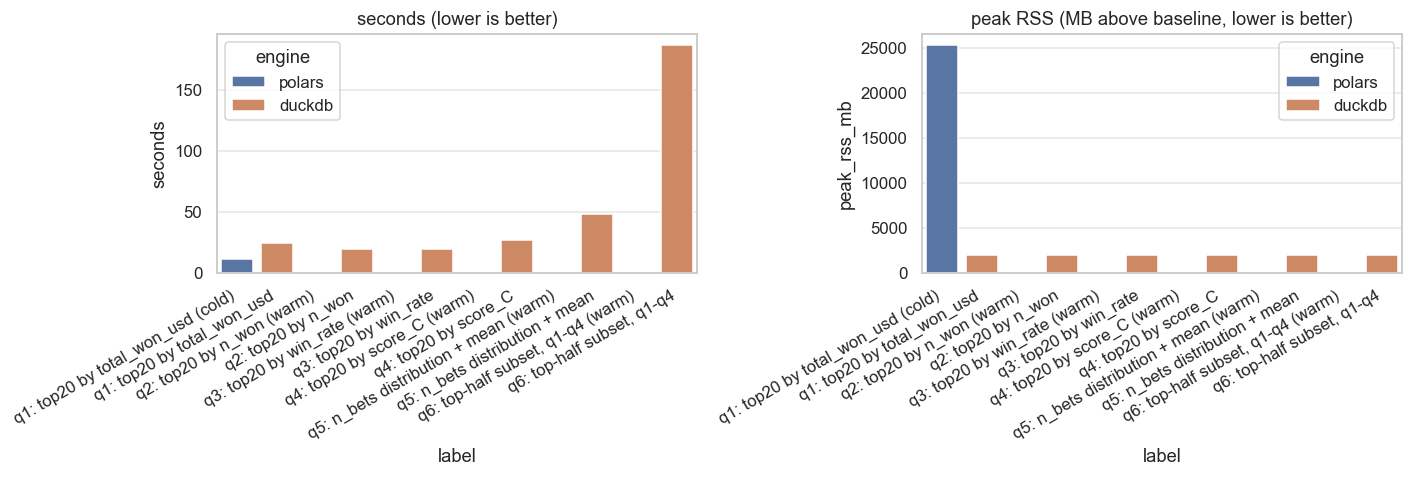

In [8]:
res = bench.df()
print(res)
import pandas as pd
rp = res.to_pandas()
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.barplot(data=rp, x='label', y='seconds', hue='engine', ax=axes[0])
axes[0].set_title('seconds (lower is better)'); axes[0].tick_params(axis='x', rotation=30)
for lbl in axes[0].get_xticklabels(): lbl.set_horizontalalignment('right')
sns.barplot(data=rp, x='label', y='peak_rss_mb', hue='engine', ax=axes[1])
axes[1].set_title('peak RSS (MB above baseline, lower is better)')
axes[1].tick_params(axis='x', rotation=30)
for lbl in axes[1].get_xticklabels(): lbl.set_horizontalalignment('right')
plt.tight_layout(); plt.show()


## Notes

- **Streaming Polars** defers materialisation; eager `pl.read_parquet` would OOM the 16 GB box on this dataset.
- **DuckDB** hash aggregations spill to `_duckdb_tmp/` when the 2 GB cap bites; that surfaces as elapsed time, not RSS.
- The **correctness assertion** in each query cell is the most important line — fast-but-wrong is worse than slow-and-right.
- This is a cold-start benchmark: each query re-runs the full pipeline. In practice, analysts pre-compute `player_stats` once and slice it many ways — that workload would favour both engines roughly equally.